In [388]:
import pandas as pd
import numpy as np
import os
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, classification_report



In [389]:
os.chdir('C:\\Users\\Phaothai\\Downloads')
df = pd.read_csv(r'Time .csv',usecols=[5,6,7,8,9,10,11,12,13,14])

df.dropna(inplace=True)
df.head()


,Temp_Avg,Air pressure_At sea lv.,relative humidity,Wind speed,sediment,Evaporation,Rain_val,R-1,W-1,water level
0,22.9,151.17,74.0,10.12,0.944,1.43,0.0,0.0,301.71,301.70
1,23.6,143.96,70.0,17.26,0.944,3.68,0.0,0.0,301.70,301.70
2,22.9,130.67,71.0,21.45,0.685,2.74,0.0,0.0,301.70,301.66
3,22.4,119.08,70.0,16.68,0.685,3.30,0.0,0.0,301.66,301.66
4,22.5,129.88,70.0,17.78,0.505,3.38,0.0,0.0,301.66,301.63


In [390]:
from sklearn.model_selection import train_test_split

In [391]:
len(df)

1460

In [392]:
df.columns

Index(['Temp_Avg', 'Air pressure_At sea lv.', 'relative humidity',
       'Wind speed', 'sediment', 'Evaporation', 'Rain_val', 'R-1', 'W-1',
       'water level'],
      dtype='object')

In [393]:
X = df[['Temp_Avg', 'Air pressure_At sea lv.', 'relative humidity',
       'Wind speed', 'sediment','Evaporation','Rain_val','R-1', 'W-1']]
y = df['water level']

In [394]:
X.head()

,Temp_Avg,Air pressure_At sea lv.,relative humidity,Wind speed,sediment,Evaporation,Rain_val,R-1,W-1
0,22.9,151.17,74.0,10.12,0.944,1.43,0.0,0.0,301.71
1,23.6,143.96,70.0,17.26,0.944,3.68,0.0,0.0,301.70
2,22.9,130.67,71.0,21.45,0.685,2.74,0.0,0.0,301.70
3,22.4,119.08,70.0,16.68,0.685,3.30,0.0,0.0,301.66
4,22.5,129.88,70.0,17.78,0.505,3.38,0.0,0.0,301.66


In [395]:
y.head()

0    301.70
1    301.70
2    301.66
3    301.66
4    301.63
Name: water level, dtype: float64

In [396]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [411]:
model = MLPRegressor(hidden_layer_sizes=(10), 
                     activation='relu',
                     solver='lbfgs',
                     max_iter=10000,
                     random_state=10000
                    )

In [412]:
model.fit(X, y)

MLPRegressor(hidden_layer_sizes=10, max_iter=10000, random_state=10000,
             solver='lbfgs')

In [413]:
os.chdir('C:\\Users\\Phaothai\\Downloads')
data = pd.read_csv(r'Test01.csv',usecols=[5,6,7,8,9,10,11,12,13,14])
X_new = data[['Temp_Avg', 'Air pressure_At sea lv.', 'relative humidity',
       'Wind speed', 'sediment','Evaporation','Rain_val','R-1', 'W-1']]  # เลือก features ที่ต้องการ
y_new = data['water level']  # เลือก target variable
X_new = scaler.fit_transform(X_new)


Root Mean Squared Error (RMSE): 0.21398362118562766
R-squared: 0.41677594257320705


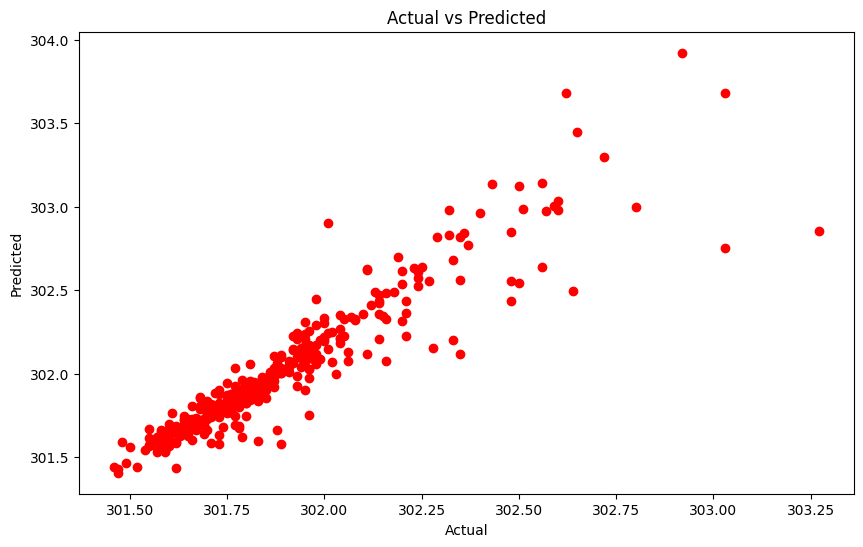

     Actual   Predicted
0    301.66  301.678713
1    301.69  301.687090
2    301.69  301.730590
3    301.66  301.728767
4    301.62  301.687733
..      ...         ...
360  301.73  301.817381
361  301.72  301.783466
362  301.73  301.767084
363  301.74  301.786268
364  301.74  301.800767

[365 rows x 2 columns]


In [414]:
y_pred = model.predict(X_new)
print("Root Mean Squared Error (RMSE):", np.sqrt(mean_squared_error(y_new, y_pred)))
print("R-squared:", r2_score(y_new, y_pred))
plt.figure(figsize=(10, 6))
plt.scatter(y_new, y_pred, color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()
comparison_Data = pd.DataFrame({'Actual': y_new, 'Predicted': y_pred})
print(comparison_Data)


In [415]:
print("R-squared:", r2_score(y_new, y_pred))

R-squared: 0.41677594257320705
